In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce Customers")

In [3]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 69.3 KB


In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


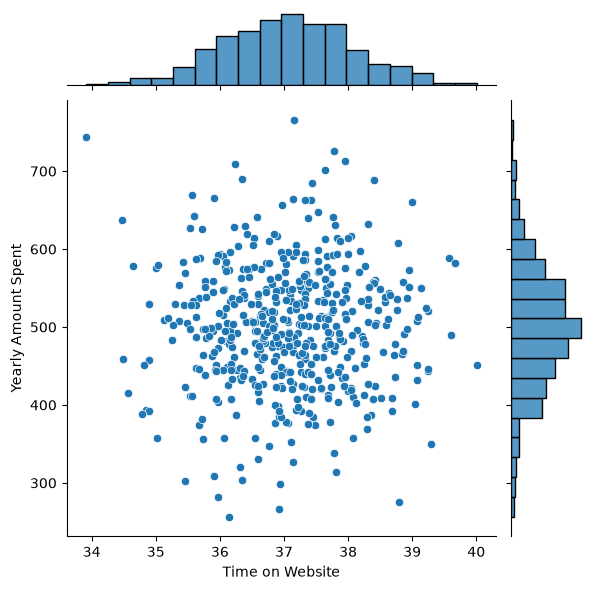

In [6]:
#EDA

sns.jointplot(x="Time on Website", y="Yearly Amount Spent",data=df)

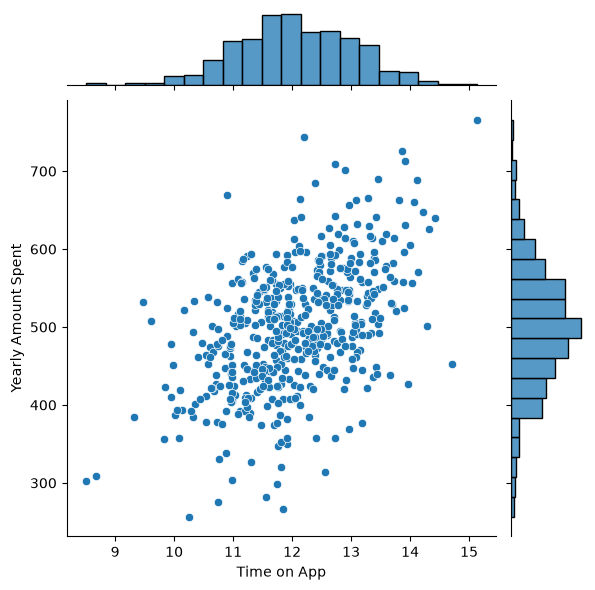

In [7]:
sns.jointplot(x="Time on App", y="Yearly Amount Spent",data=df)

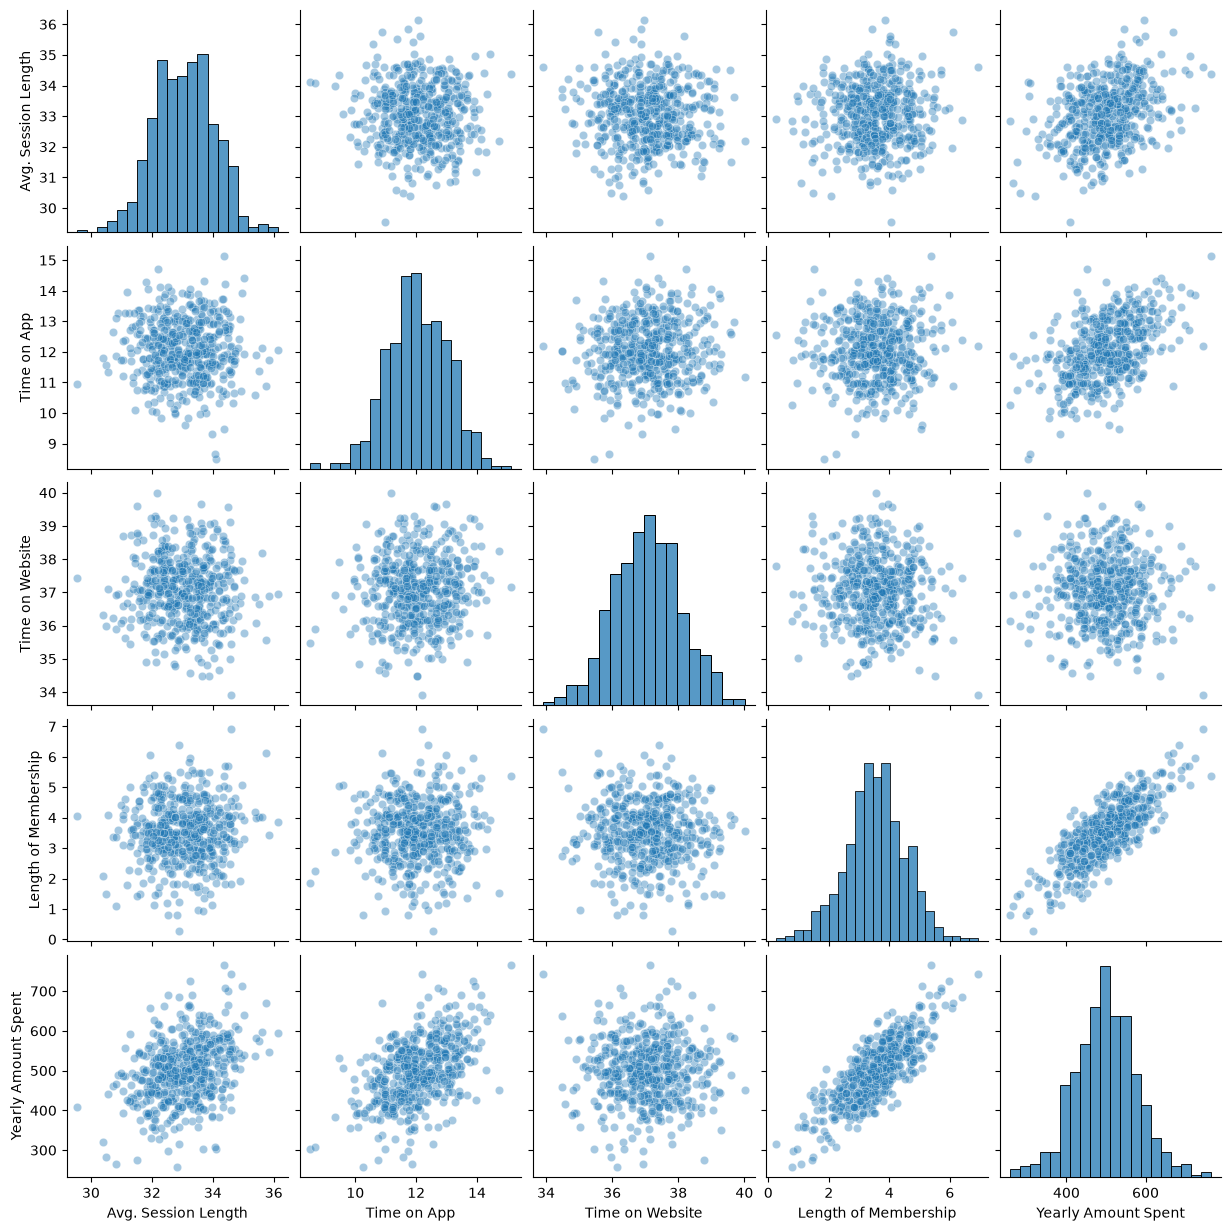

In [8]:
sns.pairplot(df, kind='scatter', plot_kws={'alpha': 0.4})

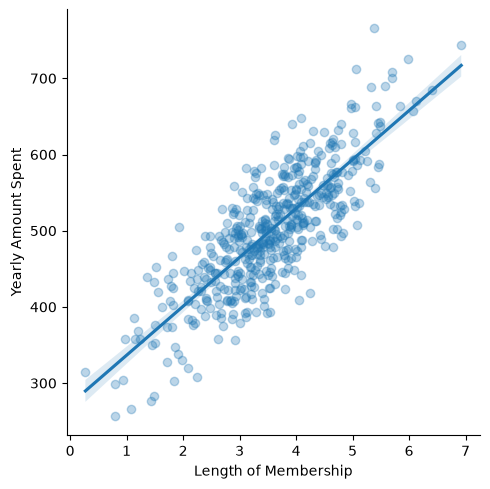

In [9]:
sns.lmplot(x = 'Length of Membership',
           y = 'Yearly Amount Spent',
           data = df,
           scatter_kws={'alpha':0.3})

In [10]:
from sklearn.model_selection import train_test_split

In [15]:
x = df[['Time on App', 'Time on Website']]
x

,Time on App,Time on Website
0,12.655651,39.577668
1,11.109461,37.268959
2,11.330278,37.110597
3,13.717514,36.721283
4,12.795189,37.536653
...,...,...
495,13.566160,36.417985
496,11.695736,37.190268
497,11.499409,38.332576
498,12.391423,36.840086


In [33]:
x = df[['Avg. Session Length',
        'Time on App',
        'Time on Website',
        'Length of Membership']]

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=2
)

In [35]:
x_train

,Avg. Session Length,Time on App,Time on Website,Length of Membership
119,33.889941,13.068639,37.540520,3.798725
335,32.133862,11.612651,39.248804,3.349245
192,33.694898,11.202670,35.493964,4.015987
178,32.635878,12.178573,35.674256,4.131755
283,33.077731,11.466984,35.675728,1.809230
...,...,...,...,...
22,31.531604,13.378563,38.734006,2.245148
72,32.386252,10.674653,38.006583,3.401522
493,32.060914,12.625433,35.539142,5.412358
15,30.737720,12.636606,36.213763,3.357847


In [23]:
# training the model

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
ln = LinearRegression()

In [37]:
ln.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.73,38.74, 0.75,61.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1063
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [38]:
ln.coef_

array([25.73355935, 38.74177284,  0.74764502, 61.43626237])

In [39]:
cdf = pd.DataFrame(ln.coef_, x.columns, columns=['coef'])
print(cdf)

                           coef
Avg. Session Length   25.733559
Time on App           38.741773
Time on Website        0.747645
Length of Membership  61.436262


In [40]:
#prdedictions

In [41]:
prdedictions = ln.predict(x_test)

In [42]:
prdedictions

array([435.06293109, 507.51083624, 500.45014818, 493.58421927,
       254.81662521, 506.92850087, 380.42947746, 573.42565426,
       483.48772013, 604.58346696, 499.95494046, 411.11013645,
       365.15179701, 584.44986191, 475.44910056, 553.90262322,
       564.56837627, 535.26297763, 441.75265965, 538.48145565,
       419.05720998, 511.21273444, 550.88173333, 531.09491979,
       765.698952  , 450.36558945, 457.09333327, 548.74767588,
       413.86195203, 534.92305953, 515.33549346, 538.66026305,
       692.60227935, 563.22927028, 456.84209485, 425.19421702,
       380.45850896, 331.48687004, 456.43092881, 283.56039174,
       531.79890137, 703.08765136, 487.3359305 , 526.39131664,
       493.65515956, 478.83492675, 486.40228653, 388.45819109,
       464.37249248, 549.21080917, 418.60053389, 371.89348693,
       375.26070649, 523.41883999, 487.27655441, 517.54274192,
       577.07387677, 478.15404036, 530.5870536 , 572.82967731,
       404.68177322, 399.69849767, 501.88890507, 445.15

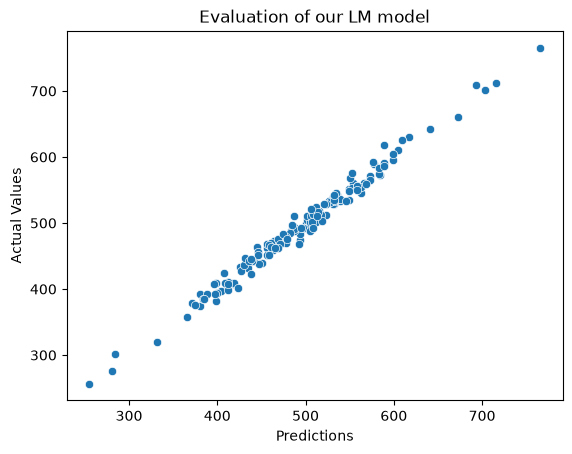

In [44]:
# Make predictions
predictions = ln.predict(x_test)

# Plot
sns.scatterplot(x=predictions, y=y_test)

plt.xlabel("Predictions")
plt.ylabel("Actual Values")
plt.title("Evaluation of our LM model")

plt.show()

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [48]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  7.54619950577141
Mean Squared Error:  91.04368442944157
RMSE:  9.541681425694403


In [54]:
#residuals

In [64]:

residuals = y_test = predictions



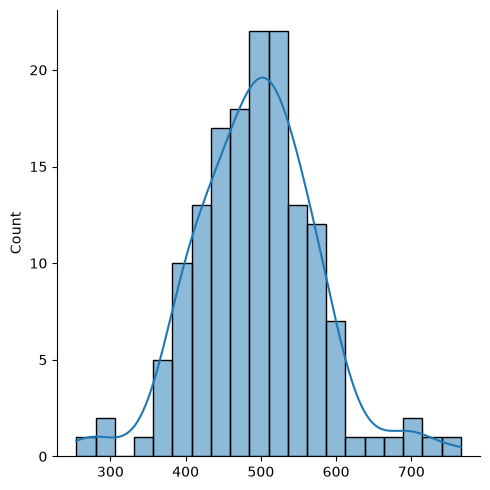

In [67]:

sns.displot(residuals, bins=20, kde=True)

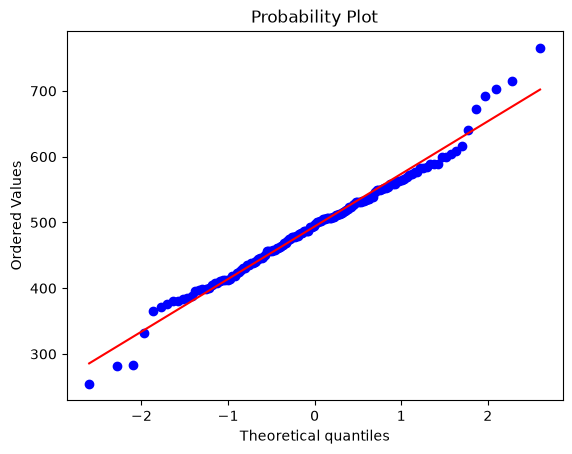

In [70]:
import pylab
import scipy.stats as status

status.probplot(residuals, dist="norm", plot=pylab)
pylab.show()